In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, SGDRegressor

from utils.visualization import BLUE, GREEN, standard_setup
standard_setup()

In [2]:
def generate_linreg(slope, intercept, noise_std, num_samples=100):
    """
    Generate linear regression data with noise.
    
    Parameters:
    - slope: Slope of the line.
    - intercept: Intercept of the line.
    - noise_std: Standard deviation of the noise.
    - num_samples: Number of samples to generate.
    
    Returns:
    - x: Array of x-values.
    - y: Array of corresponding y-values.
    """
    # Generate x values
    x = np.random.uniform(0, 10, num_samples)
    
    # Generate noise
    noise = np.random.normal(0, noise_std, num_samples)
    
    # Generate y values
    y = slope * x + intercept + noise
    
    return x, y

def plot_linreg(x, y, slope_exact, intercept_exact, x_bounds = [0, 10], y_bounds = [0, 20], loss = 'squared_error'):
    """
    Generate linear regression data with noise and plot the points along with the linear regression line.
    
    Parameters:
    - x_all: Array of x-values.
    - y_all: Array of corresponding y-values.
    - slope: Slope of the line.
    - intercept: Intercept of the line.
    - noise_std: Standard deviation of the noise.
    - num_samples: Number of samples to take from x, y. Is capped at len(x_all)
    """
    # Compute optimal linear regression line
    if loss == 'squared_error':
        model = LinearRegression()
    else:
        model = SGDRegressor(loss = loss, penalty = None)
    model.fit(x.reshape(-1, 1), y)
    x_range = np.linspace(x_bounds[0], x_bounds[1], 100)
    y_predicted = model.predict(x_range.reshape(-1, 1))
    
    # Plot linear regression line
    y_exact = slope_exact * np.array(x_range) + intercept_exact

    fig, ax = plt.subplots(figsize = (10, 6))
    ax.scatter(x, y, label='Data Points', color = 'darkblue', alpha = 0.8)
    ax.plot(x_range, y_predicted, color='g', lw = 2, label='Linear Regression Line')
    ax.plot(x_range, y_exact, color='k', lw = 2, label='Perfect Regressor')
    
    ax.set_xlim(x_bounds)
    ax.set_ylim(y_bounds)
    ax.spines[['top', 'right']].set_visible(False)

    # Add labels and legend
    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')
    ax.set_title('Linear Regression with Noise')
    legend = ax.legend(bbox_to_anchor = (-0.2, 1),
                        frameon = False)
    fig.tight_layout()
    return fig, ax

### Playing around with slopes, intercepts and noise

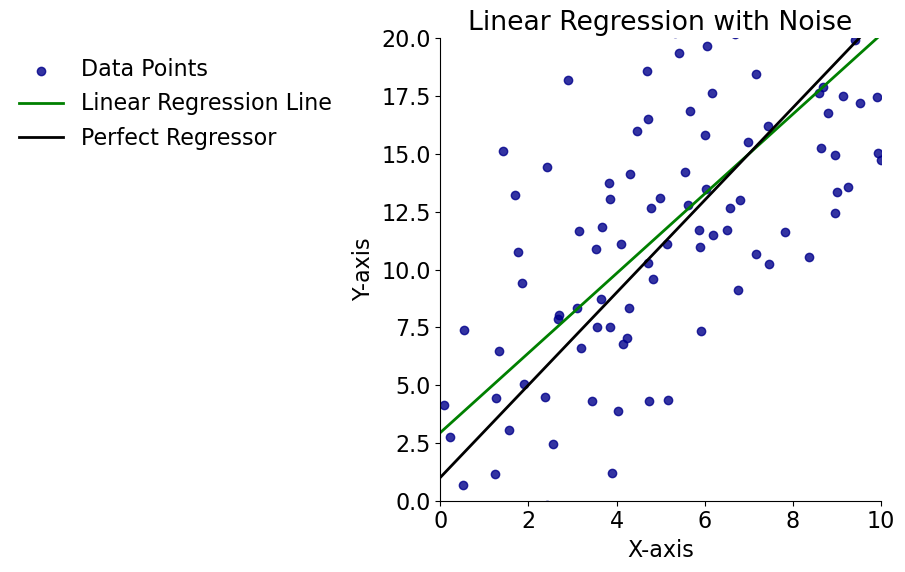

In [3]:
slope = 2
intercept = 1
noise_std = 5
num_samples = 100
x, y = generate_linreg(slope, intercept, noise_std, num_samples)

fig, ax = plot_linreg(x, y, 
                        slope, 
                        intercept, 
                        x_bounds = [0, 10], 
                        y_bounds = [0, 20])

## Now with some outliers!

Note that you can play around with the loss to see how it affects the regression line wrt the outliers. You can also look at the function which is used to calculate the regression fit. We have to use `SGDRegressor` instead of `LinearRegression` to choose the loss function because the latter does not have a loss function parameter (there does not exist a formula for alternative loss functions). You can use `SGDRegressor?` to see the options you have, you can read the following:

```python
loss : str, default='squared_error'
    The loss function to be used. The possible values are 'squared_error',
    'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'

    The 'squared_error' refers to the ordinary least squares fit.
    'huber' modifies 'squared_error' to focus less on getting outliers
    correct by switching from squared to linear loss past a distance of
    epsilon. 'epsilon_insensitive' ignores errors less than epsilon and is
    linear past that; this is the loss function used in SVR.
    'squared_epsilon_insensitive' is the same but becomes squared loss past
    a tolerance of epsilon.

    More details about the losses formulas can be found in the
    :ref:`User Guide <sgd_mathematical_formulation>`.
```

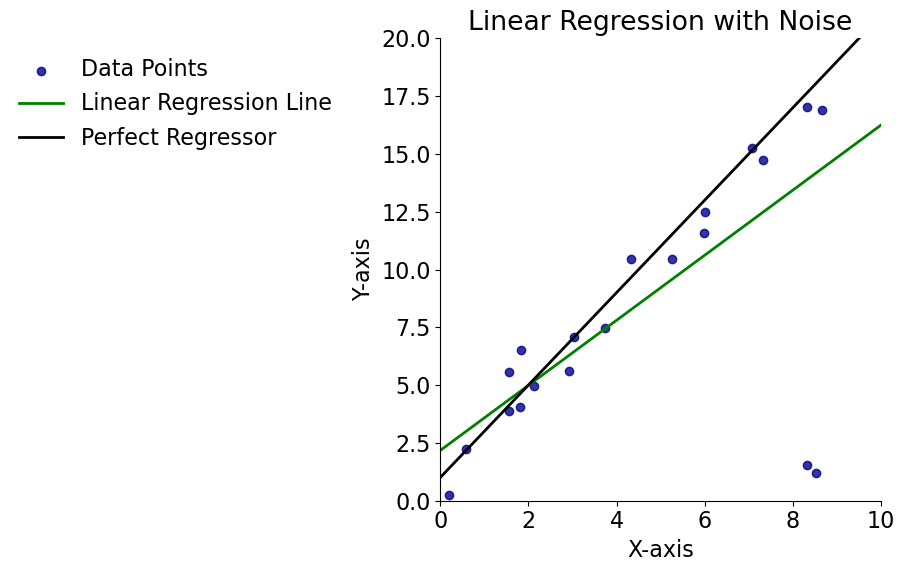

In [4]:
np.random.seed(42) # Set random seed for reproducibility

slope = 2
intercept = 1
noise_std = 1
num_samples = 20
x, y = generate_linreg(slope, intercept, noise_std, num_samples)

# Adding some outliers
num_outliers = 2
x = np.append(x, np.random.uniform(8, 9, num_outliers))
y = np.append(y, np.random.uniform(1, 2, num_outliers))

fig, ax = plot_linreg(x, y, 
                        slope, 
                        intercept, 
                        x_bounds = [0, 10], 
                        y_bounds = [0, 20],
                        loss = 'squared_error') # Alternatives: 